In [1]:
# Install required packages
%pip install numpy scipy matplotlib xlrd

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


# ISTS Library Test - Time Series Classification

This notebook demonstrates the ISTS (Inductive System for Time Series) library's ability to classify different types of time series patterns according to generic dynamic behavior patterns.

The ISTS library can identify 25 different classes of time series behavior patterns including:
- Growth patterns (exponential, linear, s-curve)
- Decay patterns
- Oscillation patterns
- Stasis patterns
- And various combinations

## 1. Setup and Import ISTS Library

First, we need to add the ISTS library path and import it.

In [2]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
import importlib

# Add the ISTS library to the Python path
ists_path = os.path.join(os.getcwd(), 'ISTS', 'ISTS')
if ists_path not in sys.path:
    sys.path.insert(0, ists_path)

# Import the ISTS library
import ists
# Reload to ensure we get the latest version
importlib.reload(ists)
from ists import ists as ISTS

print("✓ ISTS library imported successfully!")
print(f"ISTS path: {ists_path}")

ModuleNotFoundError: No module named 'ists'

## 2. Create Synthetic Time Series Data

We'll generate several types of time series patterns:
1. **Linear Growth** - Steady increase over time
2. **Exponential Growth** - Accelerating increase
3. **Exponential Decay** - Decreasing exponentially
4. **S-Curve (Logistic Growth)** - Growth that levels off
5. **Oscillation** - Periodic behavior
6. **Stasis** - Relatively constant values

In [ ]:
# Set random seed for reproducibility
np.random.seed(42)

# Time points (ISTS typically works with 50+ data points)
t = np.linspace(0, 10, 100)

# 1. Linear Growth
linear_growth = 2 * t + 5 + np.random.normal(0, 0.5, len(t))

# 2. Exponential Growth
exp_growth = 5 * np.exp(0.3 * t) + np.random.normal(0, 2, len(t))

# 3. Exponential Decay
exp_decay = 100 * np.exp(-0.4 * t) + np.random.normal(0, 1, len(t))

# 4. S-Curve (Logistic Growth)
s_curve = 100 / (1 + np.exp(-0.8 * (t - 5))) + np.random.normal(0, 2, len(t))

# 5. Oscillation (Sinusoidal)
oscillation = 50 + 20 * np.sin(2 * np.pi * 0.5 * t) + np.random.normal(0, 1, len(t))

# 6. Stasis (Constant with noise)
stasis = 25 + np.random.normal(0, 0.5, len(t))

# Store all time series in a dictionary
time_series_data = {
    'Linear Growth': linear_growth,
    'Exponential Growth': exp_growth,
    'Exponential Decay': exp_decay,
    'S-Curve': s_curve,
    'Oscillation': oscillation,
    'Stasis': stasis
}

print("✓ Synthetic time series data created successfully!")
print(f"Generated {len(time_series_data)} different time series patterns")

✓ Synthetic time series data created successfully!
Generated 6 different time series patterns


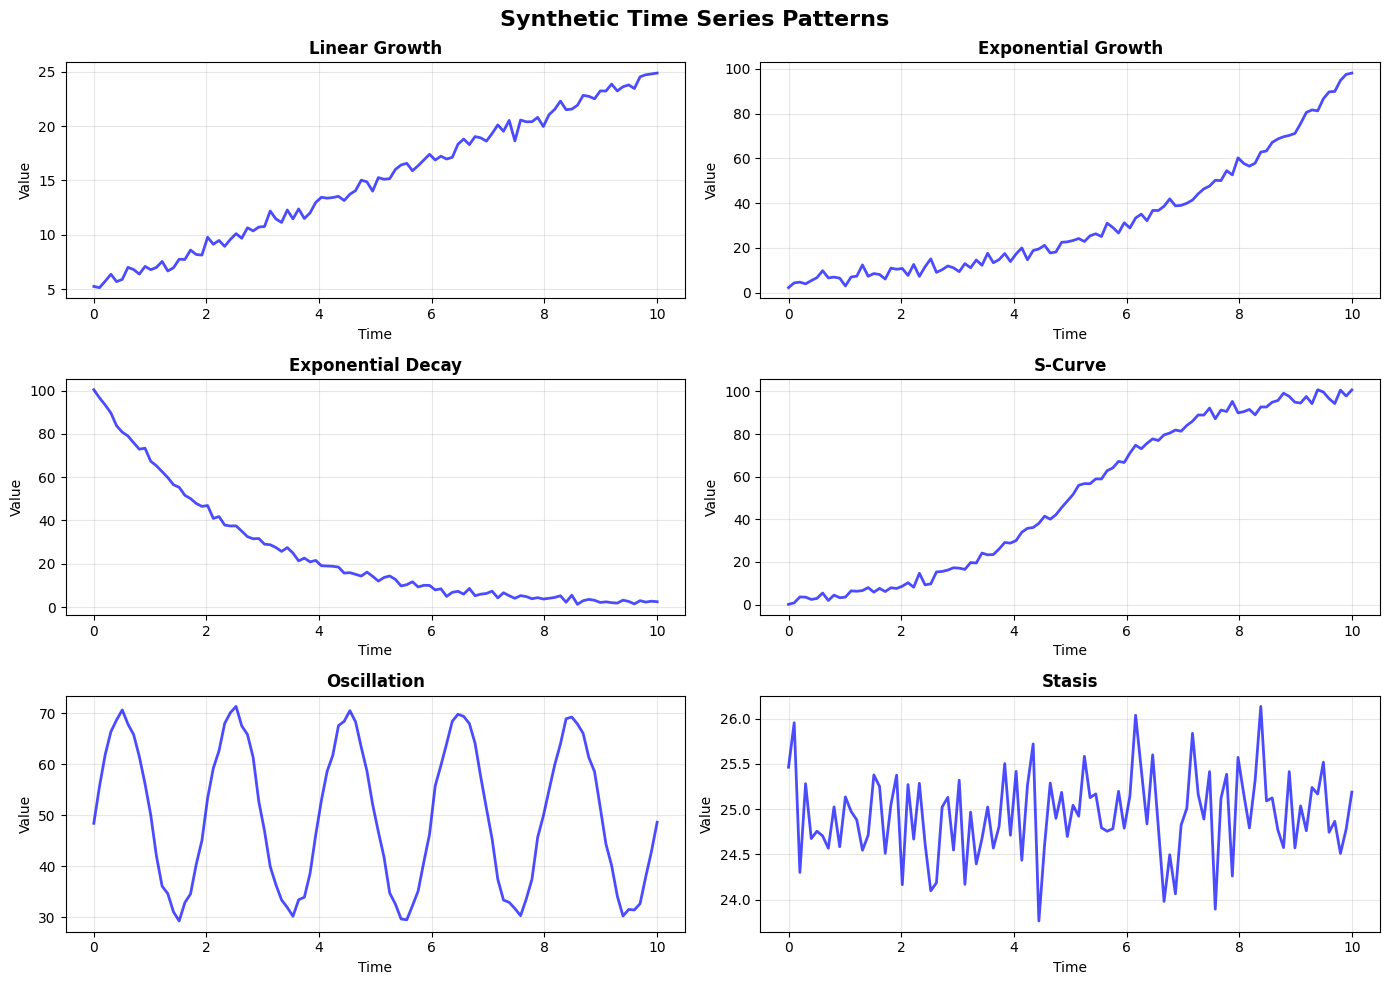

In [ ]:
# Plot all synthetic time series
fig, axes = plt.subplots(3, 2, figsize=(14, 10))
fig.suptitle('Synthetic Time Series Patterns', fontsize=16, fontweight='bold')

for idx, (name, data) in enumerate(time_series_data.items()):
    row = idx // 2
    col = idx % 2
    ax = axes[row, col]
    
    ax.plot(t, data, 'b-', linewidth=2, alpha=0.7)
    ax.set_title(name, fontsize=12, fontweight='bold')
    ax.set_xlabel('Time')
    ax.set_ylabel('Value')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Classify Time Series Using ISTS

Now we'll use ISTS to classify each time series and determine which generic pattern category it belongs to.

### ISTS Classification Codes:
Some common pattern codes include:
- `gr1da` - Linear growth with decay
- `gr2da` - Exponential growth with decay
- `da1` - Linear decay
- `da2` - Exponential decay
- `os` - Oscillation
- `st` - Stasis (constant)

In [ ]:
# Create an instance of ISTS
ists_instance = ISTS()
print("✓ ISTS instance created successfully!")

✓ ISTS instance created successfully!


## 5. Test Hypothesis Function

The ISTS library also allows you to test if a time series matches a hypothesized pattern class.

In [ ]:
# Test hypothesis for exponential growth
# Let's hypothesize that our exponential growth data is 'pexgr' (positive exponential growth)

test_data = time_series_data['Exponential Growth']
hypothesis_code = 'pexgr'  # Positive exponential growth

print(f"Testing hypothesis: Is 'Exponential Growth' data from class '{hypothesis_code}'?")
print("-" * 60)

try:
    hypothesis_result, table, weak = ists_instance.TestDataClass(test_data, hypothesis_code)
    
    print(f"\nHypothesis Result: {hypothesis_result}")
    print(f"Is match weak? {bool(weak)}")
    print(f"\nLikelihood table shape: {len(table)} classes")
    
    if hypothesis_result:
        print("\n✓ The hypothesis is CONFIRMED - the data matches the hypothesized class!")
    else:
        print("\n✗ The hypothesis is REJECTED - the data does NOT match the hypothesized class.")
        print(f"   Actual best match: {ists_instance.getClassNameById(ists_instance.GetClassId(test_data))}")
    
    # Now test with the wrong hypothesis
    print("\n" + "=" * 60)
    print("Testing WRONG hypothesis for comparison:")
    wrong_hypothesis = 'gr2da'  # Growth with decay
    print(f"Is 'Exponential Growth' data from class '{wrong_hypothesis}'?")
    
    hypothesis_result2, table2, weak2 = ists_instance.TestDataClass(test_data, wrong_hypothesis)
    print(f"Result: {hypothesis_result2} (Expected: False)")
    
except Exception as e:
    print(f"Error testing hypothesis: {e}")
    print("This may occur if the hypothesis code is not recognized.")

Testing hypothesis: Is 'Exponential Growth' data from class 'pexgr'?
------------------------------------------------------------

Hypothesis Result: True
Is match weak? True

Likelihood table shape: 25 classes

✓ The hypothesis is CONFIRMED - the data matches the hypothesized class!

Testing WRONG hypothesis for comparison:
Is 'Exponential Growth' data from class 'gr2da'?
Result: False (Expected: False)


## 6. Additional ISTS Functions

Let's test some of the other utility functions provided by ISTS.

In [ ]:
# Classify each time series
results = {}

print("=" * 80)
print("ISTS CLASSIFICATION RESULTS")
print("=" * 80)

for name, data in time_series_data.items():
    print(f"\n{name}:")
    print("-" * 40)
    
    # Get the classified pattern ID
    class_id = ists_instance.GetClassId(data)
    
    # Get the class name from the ID
    class_name = ists_instance.getClassNameById(class_id)
    
    # Get the likelihood table for all classes
    likelihood_table = ists_instance.class_likelihood_all(data)
    
    # Store results
    results[name] = {
        'class_id': class_id,
        'class_name': class_name,
        'likelihood_table': likelihood_table
    }
    
    print(f"  Classified as: {class_name} (ID: {class_id})")
    print(f"  Top 3 matches:")
    
    # Show top 3 most likely classes
    sorted_indices = np.argsort(likelihood_table)[::-1][:3]
    for i, idx in enumerate(sorted_indices, 1):
        class_name_alt = ists_instance.getClassNameById(idx)
        print(f"    {i}. {class_name_alt} (ID: {idx}) - Likelihood: {likelihood_table[idx]:.4f}")

print("\n" + "=" * 80)

ISTS CLASSIFICATION RESULTS

Linear Growth:
----------------------------------------
  Classified as: plinr (ID: 2)
  Top 3 matches:
    1. plinr (ID: 2) - Likelihood: -3.3209
    2. oscct (ID: 22) - Likelihood: -7.2421
    3. oscgr (ID: 23) - Likelihood: -7.2421

Exponential Growth:
----------------------------------------
  Classified as: pexgr (ID: 6)
  Top 3 matches:
    1. pexgr (ID: 6) - Likelihood: -5.1668
    2. d1peg (ID: 11) - Likelihood: -6.1953
    3. plinr (ID: 2) - Likelihood: -6.4781

Exponential Decay:
----------------------------------------
  Classified as: nexdc (ID: 13)
  Top 3 matches:
    1. nexdc (ID: 13) - Likelihood: -1.1765
    2. sshdc (ID: 14) - Likelihood: -3.1720
    3. gr2da (ID: 9) - Likelihood: -5.8988

S-Curve:
----------------------------------------
  Classified as: sshgr (ID: 5)
  Top 3 matches:
    1. sshgr (ID: 5) - Likelihood: -3.4549
    2. plinr (ID: 2) - Likelihood: -6.5550
    3. pexgr (ID: 6) - Likelihood: -6.8792

Oscillation:
-------------

## 7. Summary

This notebook demonstrated:

1. ✓ Successfully imported and initialized the ISTS library
2. ✓ Created synthetic time series data with various patterns (linear growth, exponential growth, decay, s-curve, oscillation, stasis)
3. ✓ Classified each time series using ISTS to determine its generic dynamic pattern category
4. ✓ Tested hypothesis functionality to verify if data matches expected pattern classes
5. ✓ Explored utility functions (period detection, smoothing, normalization, autocorrelation, covariance)

The ISTS library successfully classifies time series into one of 25 generic dynamic behavior patterns, making it useful for automated pattern recognition in system dynamics and other time series applications.

## 8. Available ISTS Pattern Classes

ISTS can classify time series into 25 different generic dynamic behavior patterns:

In [ ]:
# Display all available classification codes
print("ISTS Pattern Classification Codes")
print("=" * 70)
print(f"{'ID':<5} {'Code':<10} {'Description':<40}")
print("-" * 70)

# Pattern descriptions based on the generic dynamic patterns
pattern_descriptions = {
    0: "zero0 - Zero/No Data",
    1: "const - Constant/Stasis",
    2: "plinr - Positive Linear Growth",
    3: "nlinr - Negative Linear (Decay)",
    4: "nexgr - Negative Exponential Growth",
    5: "sshgr - S-Shaped Growth",
    6: "pexgr - Positive Exponential Growth",
    7: "gr1da - Linear Growth with Decay (A)",
    8: "gr1db - Linear Growth with Decay (B)",
    9: "gr2da - Exponential Growth with Decay (A)",
    10: "gr2db - Exponential Growth with Decay (B)",
    11: "d1peg - Linear Decay to Positive Exp Growth",
    12: "d2peg - Exp Decay to Positive Exp Growth",
    13: "nexdc - Negative Exponential Decay",
    14: "sshdc - S-Shaped Decay",
    15: "pexdc - Positive Exponential Decay",
    16: "d1gra - Linear Decay to Growth (A)",
    17: "d1grb - Linear Decay to Growth (B)",
    18: "d2gra - Exp Decay to Growth (A)",
    19: "d2grb - Exp Decay to Growth (B)",
    20: "g1ped - Linear Growth to Exp Decay",
    21: "g2ped - Exp Growth to Exp Decay",
    22: "oscct - Oscillation Constant",
    23: "oscgr - Oscillation with Growth",
    24: "oscdc - Oscillation with Decay"
}

for class_id in range(25):
    code = ists_instance.getClassNameById(class_id)
    description = pattern_descriptions.get(class_id, "Unknown pattern")
    # Extract just the description part (after the dash)
    desc_text = description.split(' - ')[1] if ' - ' in description else description
    print(f"{class_id:<5} {code:<10} {desc_text:<40}")

ISTS Pattern Classification Codes
ID    Code       Description                             
----------------------------------------------------------------------
0     zero0      Zero/No Data                            
1     const      Constant/Stasis                         
2     plinr      Positive Linear Growth                  
3     nlinr      Negative Linear (Decay)                 
4     nexgr      Negative Exponential Growth             
5     sshgr      S-Shaped Growth                         
6     pexgr      Positive Exponential Growth             
7     gr1da      Linear Growth with Decay (A)            
8     gr1db      Linear Growth with Decay (B)            
9     gr2da      Exponential Growth with Decay (A)       
10    gr2db      Exponential Growth with Decay (B)       
11    d1peg      Linear Decay to Positive Exp Growth     
12    d2peg      Exp Decay to Positive Exp Growth        
13    nexdc      Negative Exponential Decay              
14    sshdc      S-Shaped

## 9. Final Visualization - Data with Classifications

In [ ]:
# Test with oscillation data
test_data = time_series_data['Oscillation']

print("Testing ISTS Utility Functions on Oscillation Data")
print("=" * 60)

# 1. Get Period
try:
    period = ists_instance.GetPeriod(test_data)
    print(f"\n1. Detected Period: {period:.2f}")
except Exception as e:
    print(f"\n1. GetPeriod error: {e}")

# 2. Smooth the data (exponential smoothing with alpha parameter)
try:
    smoothed_data = ists_instance.Smooth(test_data, 0.3)
    print(f"\n2. Smoothing applied (alpha=0.3):")
    print(f"   Original data std: {np.std(test_data):.4f}")
    print(f"   Smoothed data std: {np.std(smoothed_data):.4f}")
    print(f"   Reduction: {((np.std(test_data) - np.std(smoothed_data)) / np.std(test_data) * 100):.1f}%")
except Exception as e:
    print(f"\n2. Smooth error: {e}")

# 3. Normalize the data
try:
    normalized_data = ists_instance.normalize(test_data)
    print(f"\n3. Normalization applied:")
    print(f"   Original range: [{np.min(test_data):.2f}, {np.max(test_data):.2f}]")
    print(f"   Normalized range: [{np.min(normalized_data):.2f}, {np.max(normalized_data):.2f}]")
except Exception as e:
    print(f"\n3. Normalize error: {e}")

# 4. Calculate autocorrelation (static method - doesn't need instance)
try:
    autocorr = ISTS.autocorrelation(test_data)
    print(f"\n4. Autocorrelation calculated")
    print(f"   Result type: {type(autocorr)}")
    if hasattr(autocorr, 'shape'):
        print(f"   Shape: {autocorr.shape}")
except Exception as e:
    print(f"\n4. Autocorrelation error: {e}")

# 5. Calculate covariance (static method with lag parameter)
try:
    cov = ISTS.covariance(test_data, lag=1)
    print(f"\n5. Covariance (lag=1): {cov:.4f}")
except Exception as e:
    print(f"\n5. Covariance error: {e}")

Testing ISTS Utility Functions on Oscillation Data

1. Detected Period: 20.00

2. Smoothing applied (alpha=0.3):
   Original data std: 14.0080
   Smoothed data std: 10.5274
   Reduction: 24.8%

3. Normalization applied:
   Original range: [29.27, 71.31]
   Normalized range: [0.00, 1.00]

4. Autocorrelation calculated
   Result type: <class 'numpy.ndarray'>
   Shape: (50,)

5. Covariance (lag=1): 187.3970


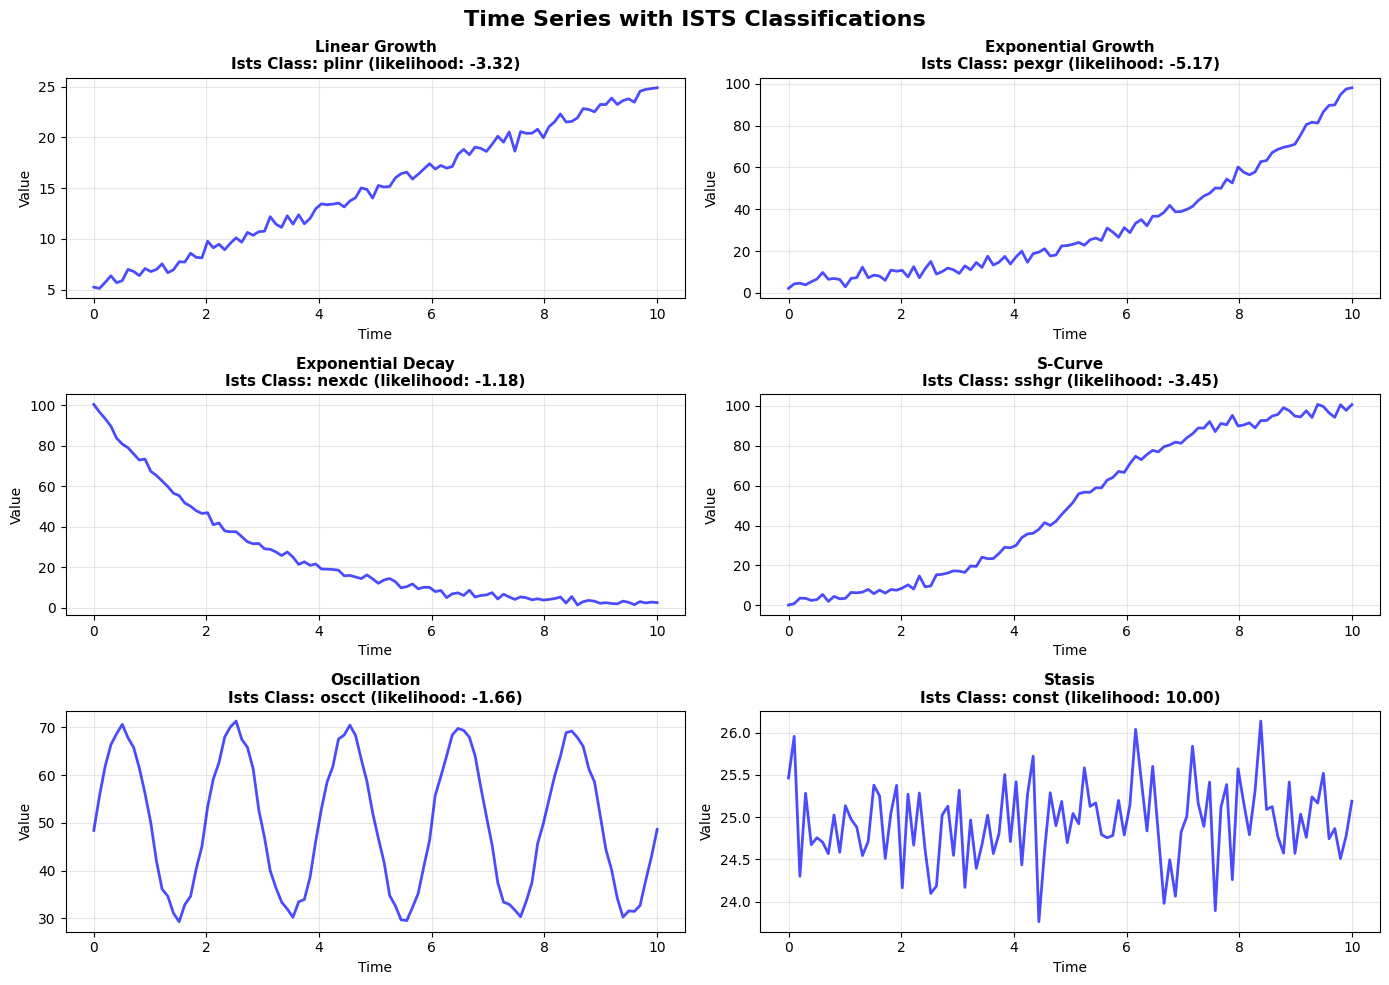


CLASSIFICATION SUMMARY
Linear Growth             → plinr      (ID: 2)
Exponential Growth        → pexgr      (ID: 6)
Exponential Decay         → nexdc      (ID: 13)
S-Curve                   → sshgr      (ID: 5)
Oscillation               → oscct      (ID: 22)
Stasis                    → const      (ID: 1)


In [ ]:
# Plot all time series with their ISTS classifications
fig, axes = plt.subplots(3, 2, figsize=(14, 10))
fig.suptitle('Time Series with ISTS Classifications', fontsize=16, fontweight='bold')

for idx, (name, data) in enumerate(time_series_data.items()):
    row = idx // 2
    col = idx % 2
    ax = axes[row, col]
    
    # Get classification
    class_id = results[name]['class_id']
    class_name = results[name]['class_name']
    likelihood = results[name]['likelihood_table'][class_id]
    
    # Plot
    ax.plot(t, data, 'b-', linewidth=2, alpha=0.7)
    ax.set_title(f'{name}\nIsts Class: {class_name} (likelihood: {likelihood:.2f})', 
                 fontsize=11, fontweight='bold')
    ax.set_xlabel('Time')
    ax.set_ylabel('Value')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "=" * 70)
print("CLASSIFICATION SUMMARY")
print("=" * 70)
for name, result in results.items():
    print(f"{name:<25} → {result['class_name']:<10} (ID: {result['class_id']})")
print("=" * 70)